# Exploration du dataset et idées pour le modèle de prédiction

## Dataset description

### 1. Coûts d'exposition mensuels (/data/costs)
* **EID** : Identifiant unique de l'élément du réseau.
* **MONTH** : Mois au format YYYY-MM (ex. 2022-06).
* **PEAKID** : Profil horaire (0 = OFF / Off-Peak, 1 = ON / On-Peak).
* **C** : Coût d'exposition mensuel associé par le marché.

### 2. Prix réalisés horaires (/data/prices)
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage au format ISO 8601 sans timezone, résolution horaire, suivant la convention Hour Ending (HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **PRICEREALIZED** : Prix réalisé horaire (les valeurs manquantes équivalent à 0).

### 3. Simulations mensuelles (/data/sim_monthly)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3) correspondant à trois méthodes de prédiction différentes.
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) expliquant une partie de l'intensité (ACTIVATIONLEVEL), dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) associées à l'intensité. Non-additives car elles présentent des chevauchements avec les impacts par source.
* **PSM** : Prix simulé par les simulations mensuelles associé à l'élément pour l'heure considérée.

### 4. Simulations journalières (/data/sim_daily)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3).
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) avec chevauchements (non-additives).
* **PSD** : Prix simulé par les simulations journalières associé à l'élément pour l'heure considérée.

## 0.Librairies et import general

In [2]:
#Charger les libraries nécessaires
import sys
import os
import duckdb
# Add the project root to the Python path
sys.path.append(os.path.abspath('..'))

import importlib
import pandas as pd
from utilities import customdataloader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Ajuster ce chemin selon votre setup Google Drive Desktop
DATA_ROOT = r"G:\.shortcut-targets-by-id\1SR7TxhNQjFyS8f2bbuo9pcLvzNMLBMwY\CSD\data"

In [4]:
# Instancier le loader
loader = customdataloader(
    pricefile=os.path.join(DATA_ROOT, 'prices', 'prices.parquet'),
    costfile=os.path.join(DATA_ROOT, 'costs', 'costs.parquet'),
    dsimfile=[os.path.join(DATA_ROOT, 'sim_daily', f'sim_daily_{y}.parquet') for y in [2020,2021,2022,2023,2024]],
    msimfile=[os.path.join(DATA_ROOT, 'sim_monthly', f'sim_monthly_{y}.parquet') for y in [2020,2021,2022,2023,2024]],
)

In [5]:
# Chargement complet de costs + prices (ces fichiers sont petits)
costs = pd.read_parquet(os.path.join(DATA_ROOT, 'costs', 'costs.parquet'))
prices = pd.read_parquet(os.path.join(DATA_ROOT, 'prices', 'prices.parquet'))

print(f"costs:  {costs.shape[0]:,} rows  |  prices: {prices.shape[0]:,} rows")

costs:  9,092 rows  |  prices: 453,167 rows


## 1.Load pour le mois de fevrier 2020

In [6]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-02'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-01-07'    # 7 de M : moment de décision
 
# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-02: 9076 triplets (4538 EIDs uniques)


In [7]:
filterdf.head(5) # Afficher les 5 premiers triplets candidats

,EID,MONTH,PEAKID
0,767,2020-02,0
1,774,2020-02,0
2,784,2020-02,0
3,788,2020-02,0
4,800,2020-02,0


In [8]:
#Simulations mensuelles (pour le mois cible)
monthly_sim = loader.get_monthly_data(filterdf)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (9475344, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,877,2020-02-01 00:00:00,0,0.0050,0.0,0.0,0.0,0.0,0.0,0.0045,0.0,0.0
1,1,877,2020-02-01 01:00:00,0,0.0048,0.0,0.0,0.0,0.0,0.0,0.0043,0.0,0.0
2,1,877,2020-02-01 02:00:00,0,0.0047,0.0,0.0,0.0,0.0,0.0,0.0042,0.0,0.0
3,1,877,2020-02-01 03:00:00,0,0.0046,0.0,0.0,0.0,0.0,0.0,0.0041,0.0,0.0
4,1,877,2020-02-01 04:00:00,0,0.0046,0.0,0.0,0.0,0.0,0.0,0.0041,0.0,0.0


In [9]:
# filterdf pour daily sims = mois M (décision), pas M+1 (cible)
daily_filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [CUTOFF_DATE[:7]] * len(known_eids) * 2,  # '2020-01' au lieu de '2020-02'
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})

len(daily_filterdf)

9076

In [10]:
#Simulations journalières (jusqu'au cutoff)
daily_sim = loader.get_daily_data(daily_filterdf, cutoff_date=CUTOFF_DATE)
print(f"Sim daily: {daily_sim.shape}")
daily_sim.head()

Sim daily: (2287152, 13)


,SCENARIOID,EID,DATETIME,PEAKID,d_ACTIVATIONLEVEL,d_WINDIMPACT,d_SOLARIMPACT,d_HYDROIMPACT,d_NONRENEWBALIMPACT,d_EXTERNALIMPACT,d_LOADIMPACT,d_TRANSMISSIONOUTAGEIMPACT,d_PSD
0,1,1004,2020-01-01 01:00:00,0,38.708302,29.836201,0.0,5.1491,4.5077,1.8999,-1.7547,0.7521,0.0
1,1,1004,2020-01-01 02:00:00,0,36.706100,30.130400,0.0,5.0419,2.3242,2.3331,-1.9585,0.8112,0.0
2,1,1004,2020-01-01 03:00:00,0,34.932899,28.426901,0.0,4.9972,2.6361,2.2061,-2.0237,0.8272,0.0
3,1,1004,2020-01-01 04:00:00,0,32.565601,25.919600,0.0,4.9808,2.6559,2.2419,-1.7460,0.9067,0.0
4,1,1004,2020-01-01 05:00:00,0,31.032101,24.558399,0.0,4.9834,2.4918,2.1106,-1.6371,0.9586,0.0


In [11]:
(daily_filterdf["EID"]==filterdf["EID"]).value_counts()

EID
True    9076
Name: count, dtype: int64

## 1.Comprendre la structure de base du data pour un seul mois, soit le 2020-02

In [12]:
# Combien d'EIDs, heures, scénarios
print(monthly_sim.groupby('SCENARIOID')['EID'].nunique())
print(f"Heures par EID/scénario: {monthly_sim.groupby(['SCENARIOID','EID']).size().describe()}")
print(f"Répartition PEAKID:\n{monthly_sim['PEAKID'].value_counts()}")

SCENARIOID
1    4538
2    4538
3    4538
Name: EID, dtype: int64
Heures par EID/scénario: count    13614.0
mean       696.0
std          0.0
min        696.0
25%        696.0
50%        696.0
75%        696.0
max        696.0
dtype: float64
Répartition PEAKID:
PEAKID
0    5118864
1    4356480
Name: count, dtype: int64


Structure des données monthly_sim

- **3 scénarios** de simulation (SCENARIOID 1, 2, 3), chacun contenant exactement **4 538 EIDs**.
- Chaque combinaison (scénario, EID) contient **696 heures** → correspond aux 29 jours × 24h de février 2020 (année bissextile).
- **Répartition ON/OFF-peak** : plus de lignes OFF-peak (5 118 864) que ON-peak (4 356 480), ce qui reflète le fait que les heures hors-pointe (nuits, weekends) sont plus nombreuses.
- **Total** : 9 475 344 lignes = 3 × 4 538 × 696
- Les `filterdf` et `daily_filterdf` partagent les mêmes EIDs mais visent des mois différents : `filterdf` cible M+1 (simulations mensuelles futures) et `daily_filterdf` cible M (observations journalières passées jusqu'au cutoff).

### 2.Vérifier les valeurs manquantes et les zéros

In [13]:
# PSM semble souvent à 0 — vérifier la sparsité
print(monthly_sim.isnull().sum())
print(f"PSM == 0: {(monthly_sim['m_PSM'] == 0).mean():.2%}")
print(f"ACTIVATIONLEVEL == 0: {(monthly_sim['m_ACTIVATIONLEVEL'] == 0).mean():.2%}")

SCENARIOID                    0
EID                           0
DATETIME                      0
PEAKID                        0
m_ACTIVATIONLEVEL             0
m_WINDIMPACT                  0
m_SOLARIMPACT                 0
m_HYDROIMPACT                 0
m_NONRENEWBALIMPACT           0
m_EXTERNALIMPACT              0
m_LOADIMPACT                  0
m_TRANSMISSIONOUTAGEIMPACT    0
m_PSM                         0
dtype: int64
PSM == 0: 99.72%
ACTIVATIONLEVEL == 0: 3.73%


### 3. Distributions des variables clés

In [14]:
monthly_sim[['m_ACTIVATIONLEVEL','m_WINDIMPACT','m_SOLARIMPACT','m_HYDROIMPACT',
             'm_NONRENEWBALIMPACT','m_EXTERNALIMPACT','m_PSM']].describe()

,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_PSM
count,9.475344e+06,9.475344e+06,9.475344e+06,9.475344e+06,9.475344e+06,9.475344e+06,9.475344e+06
mean,2.527923e+01,1.612429e+01,1.066986e-01,-1.918851e+00,7.558744e+00,1.120506e+00,-1.039692e-01
std,2.105917e+01,1.857158e+04,1.520938e+02,5.276585e+03,1.443928e+04,1.788902e+03,3.441647e+00
min,0.000000e+00,-4.901827e+05,-5.852708e+04,-1.622958e+07,-4.440824e+07,-3.163503e+05,-8.650000e+02
25%,7.822300e+00,0.000000e+00,0.000000e+00,-2.536500e+00,0.000000e+00,-1.050100e+00,-0.000000e+00
50%,2.134080e+01,3.710700e+00,0.000000e+00,0.000000e+00,8.492100e+00,0.000000e+00,0.000000e+00
75%,3.821940e+01,1.533260e+01,1.900000e-03,2.069200e+00,2.296470e+01,1.153600e+00,0.000000e+00
max,2.948008e+02,5.715320e+07,4.610355e+05,2.768222e+05,1.203789e+06,5.089868e+06,1.745121e+02


### 4. Comparer les 3 scénarios

In [15]:
# Est-ce que les scénarios divergent beaucoup ?
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].mean()

,m_ACTIVATIONLEVEL,m_PSM
SCENARIOID,,
1,24.791637,-0.072150
2,25.579535,-0.103482
3,25.466507,-0.136275


### 5. Le lien pour simulation vs profitabilité

In [16]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 71.51%


In [17]:
# Comprendre la distribution
print(f"Total triplets dans analysis: {len(analysis)}")
print(f"COST == 0: {(analysis['COST'] == 0).sum()} ({(analysis['COST'] == 0).mean():.2%})")
print(f"PRICE == 0: {(analysis['PRICE'] == 0).sum()} ({(analysis['PRICE'] == 0).mean():.2%})")

# Parmi les "profitables", combien ont simplement COST=0 ?
prof = analysis[analysis['profitable']]
print(f"\nParmi les profitables:")
print(f"  COST == 0: {(prof['COST'] == 0).sum()} ({(prof['COST'] == 0).mean():.2%})")
print(f"  PRICE == 0: {(prof['PRICE'] == 0).sum()}")

Total triplets dans analysis: 344
COST == 0: 226 (65.70%)
PRICE == 0: 67 (19.48%)

Parmi les profitables:
  COST == 0: 226 (91.87%)
  PRICE == 0: 0


In [18]:
# Vrais candidats : ceux qui ont un coût non-nul
real = analysis[analysis['COST'] != 0]
print(f"Vrais candidats (COST != 0): {len(real)}")
print(f"% profitable parmi vrais: {(real['PROFIT'] > 0).mean():.2%}")

Vrais candidats (COST != 0): 118
% profitable parmi vrais: 16.95%


Mon pipeline de sélection doit filtrer les EIDs avec COST=0, sinon on risque de remplir les 10-100 candidats avec des faux positifs qui ne génèrent aucun profit réel. 

In [19]:
# Refaire l'exploration sur les vrais candidats seulement
real_analysis = pd.merge(sim_agg, target_profits[target_profits['COST'] != 0], on=['EID','PEAKID'], how='inner')
real_analysis['profitable'] = real_analysis['PROFIT'] > 0
real_analysis.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,47.525475,16.483034,-1.263298,-1287.313965,1832.561035,-257.111511
True,59.898460,21.322739,-2.662927,-2874.342285,2357.592285,-5010.350586


In [20]:
real_analysis['price_cost_ratio'] = real_analysis['PRICE'].abs() / (real_analysis['COST'].abs() + 1e-6)
real_analysis.groupby('profitable')['price_cost_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
profitable,,,,,,,,
False,98.0,0.094494,0.193091,0.00000,0.0000,0.000000,0.074342,0.790390
True,20.0,3.372689,3.413120,1.09565,1.2232,1.861546,3.659616,12.165228


In [21]:
real_analysis['sim_cost_ratio'] = real_analysis['sum_psm'].abs() / (real_analysis['COST'].abs() + 1e-6)
real_analysis.groupby('profitable')['sim_cost_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
profitable,,,,,,,,
False,98.0,2.065894,7.667545,0.0,0.0,0.000000,0.284449,60.860008
True,20.0,4.450527,10.360726,0.0,0.0,0.093871,2.581364,41.255447


In [22]:
# Corrélations sur les vrais candidats
for col in ['mean_activation','std_activation','sum_psm','sim_cost_ratio']:
    corr = real_analysis[col].corr(real_analysis['profitable'].astype(float))
    print(f"{col}: corr={corr:.3f}")

# Et teste le top-N par activation élevée (pas basse!)
for top_n in [10, 20, 30]:
    top = real_analysis.nlargest(top_n, 'mean_activation')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (activation haute): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

mean_activation: corr=0.219
std_activation: corr=0.202
sum_psm: corr=-0.151
sim_cost_ratio: corr=0.110
Top 10 (activation haute): 4 profitables, precision=40.00%
Top 20 (activation haute): 8 profitables, precision=40.00%
Top 30 (activation haute): 10 profitables, precision=33.33%


In [23]:
# Top-N par sum_psm le plus négatif (= |prix simulé| le plus élevé)
for top_n in [10, 20, 30]:
    top = real_analysis.nsmallest(top_n, 'sum_psm')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (sum_psm plus négatif): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

# Et combiner les deux signaux
real_analysis['score'] = real_analysis['mean_activation'] * 0.5 + real_analysis['sum_psm'].abs() * 0.5 / real_analysis['sum_psm'].abs().max()
for top_n in [10, 20, 30]:
    top = real_analysis.nlargest(top_n, 'score')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (combiné): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

Top 10 (sum_psm plus négatif): 4 profitables, precision=40.00%
Top 20 (sum_psm plus négatif): 7 profitables, precision=35.00%
Top 30 (sum_psm plus négatif): 9 profitables, precision=30.00%
Top 10 (combiné): 4 profitables, precision=40.00%
Top 20 (combiné): 8 profitables, precision=40.00%
Top 30 (combiné): 10 profitables, precision=33.33%


In [24]:
# Creuser le PSM par scénario
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
real_analysis.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,19.379974,0.101645,0.652364,23.668253,-1.502798
True,31.407726,0.100545,-3.133357,17.304052,0.515109


#-----------------------------------------------------
* Répéter l'analyse sur un mois d'été pour comparer
* Est-ce que solar devient discriminant en juillet ?
* Est-ce que le pattern hydro persiste ?

#----------------------------------------------------

## 2.Load pour le mois de juillet 2020

In [21]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-07'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-06-07'    # 7 de M : moment de décision

# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf_summer = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf_summer)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-07: 9272 triplets (4636 EIDs uniques)


In [22]:
#Simulations mensuelles (pour le juillet 2020)
monthly_sim = loader.get_monthly_data(filterdf_summer)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (10347552, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,1125,2020-07-01 00:00:00,0,16.204700,17.696899,0.0,21.739901,-16.5709,2.9050,-4.2305,0.2692,0.0
1,1,1125,2020-07-01 01:00:00,0,33.791302,12.291300,0.0,20.522800,7.3250,-0.4169,-1.5031,0.7115,0.0
2,1,1125,2020-07-01 02:00:00,0,34.613602,13.211900,0.0,18.913799,9.5785,0.0568,-2.6638,0.7033,0.0
3,1,1125,2020-07-01 03:00:00,0,35.992298,19.577801,0.0,17.608200,6.3008,0.1714,-3.1557,0.6332,0.0
4,1,1125,2020-07-01 04:00:00,0,30.911400,16.920300,0.0,16.605801,5.6973,-0.8246,-2.9754,0.6839,0.0


## 2.Comprendre la structure de base du data pour un seul mois, soit le 2020-07

### 5. Le lien pour simulation vs profitabilité (mois juillet 2020)

In [23]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf_summer.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 59.81%


In [24]:
# Comparer les distributions profitable vs non-profitable (mois de juillet 2020)
analysis.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,50.352848,18.202635,-2.180924,-2435.510742,1689.099365,-135.476059
True,47.705132,18.665056,-3.085272,-3434.503418,218.009460,-1124.231445


In [25]:
# Creuser le PSM par scénario (mois de juillet 2020)
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
analysis.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,11.423365,-0.074705,35.881599,24.516161,-24.770321
True,20.337563,0.114054,1.634680,13.879215,3.869126


Corrélation entre les variables pour une exploration plus visuelle

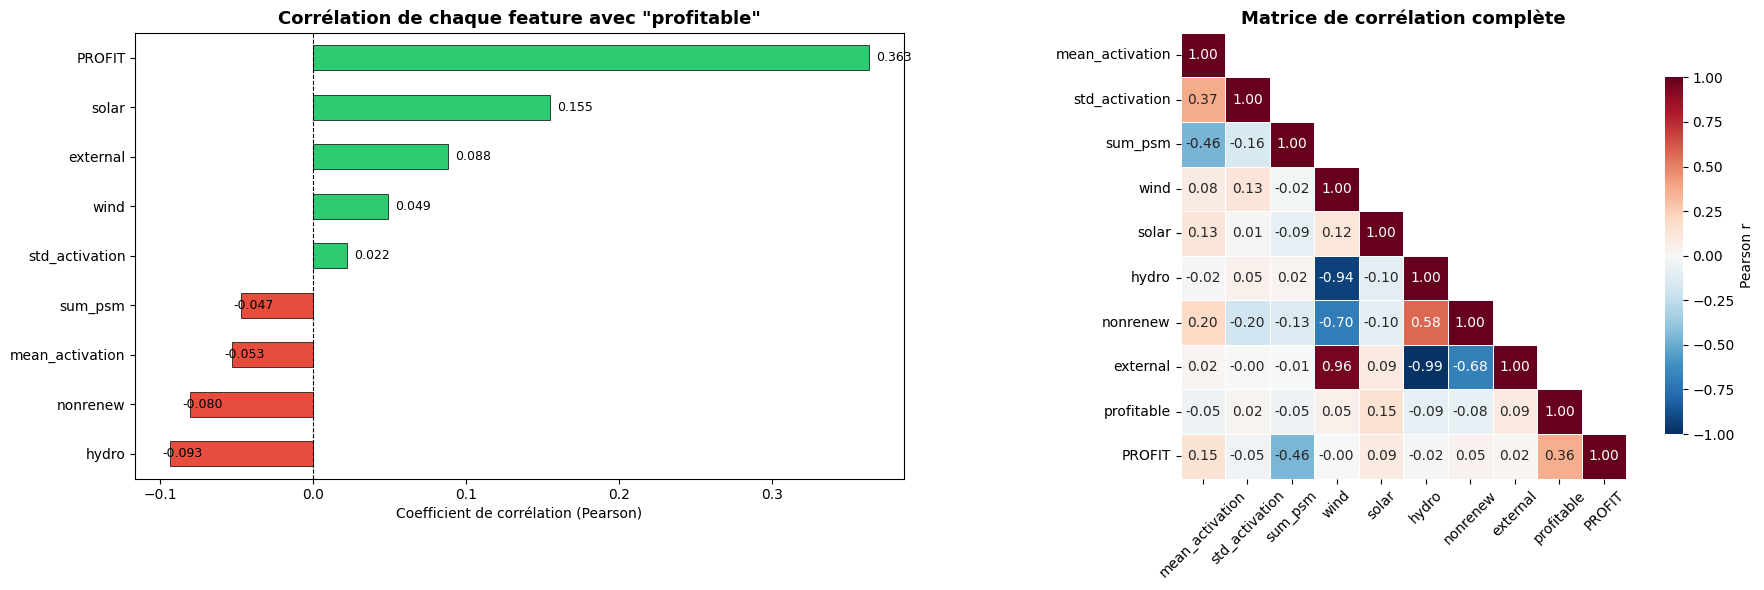


📊 Corrélations avec 'profitable' (triées par valeur absolue) :


,Feature,Corrélation,|Corrélation|,Signal
0,PROFIT,0.363017,0.363017,🟢 Fort
1,solar,0.154677,0.154677,🟢 Fort
2,hydro,-0.093272,0.093272,🟡 Modéré
3,external,0.087926,0.087926,🟡 Modéré
4,nonrenew,-0.080445,0.080445,🟡 Modéré
5,mean_activation,-0.052860,0.052860,🟡 Modéré
6,wind,0.048943,0.048943,🔴 Faible
7,sum_psm,-0.047115,0.047115,🔴 Faible
8,std_activation,0.022010,0.022010,🔴 Faible


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_cols = ['mean_activation','std_activation','sum_psm','wind','solar','hydro','nonrenew','external']

# Merge tout ensemble
full_analysis = pd.merge(sim_agg, sim_impacts, on=['EID','PEAKID'])
full_analysis = pd.merge(full_analysis, target_profits, on=['EID','PEAKID'], how='inner')
full_analysis['profitable'] = (full_analysis['PROFIT'] > 0).astype(int)

# --- 1. Bar chart : corrélation avec profitabilité ---
corr_prof = full_analysis[feature_cols + ['profitable','PROFIT']].corr()['profitable'].drop('profitable').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_prof.values]
corr_prof.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Corrélation de chaque feature avec "profitable"', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient de corrélation (Pearson)')
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for i, (val, name) in enumerate(zip(corr_prof.values, corr_prof.index)):
    axes[0].text(val + 0.005 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)

# --- 2. Heatmap : matrice de corrélation complète ---
corr_matrix = full_analysis[feature_cols + ['profitable','PROFIT']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
axes[1].set_title('Matrice de corrélation complète', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 3. Tableau récapitulatif trié ---
print("\n📊 Corrélations avec 'profitable' (triées par valeur absolue) :")
corr_abs = corr_prof.abs().sort_values(ascending=False)
summary = pd.DataFrame({
    'Feature': corr_abs.index,
    'Corrélation': [corr_prof[f] for f in corr_abs.index],
    '|Corrélation|': corr_abs.values,
    'Signal': ['🟢 Fort' if v > 0.15 else '🟡 Modéré' if v > 0.05 else '🔴 Faible' for v in corr_abs.values]
})
summary

In [27]:
# Tester la magnitude totale des impacts comme feature (TOUJOURS MOIS DE JUILLET 2020)
sim_impacts['impact_magnitude'] = sim_impacts[['wind','solar','hydro','nonrenew','external']].abs().sum(axis=1)
impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')['impact_magnitude'].describe()

,count,mean,std,min,25%,50%,75%,max
profitable,,,,,,,,
False,127.0,136.210678,717.318665,0.0,44.973675,59.600376,75.161598,8064.375977
True,189.0,65.157211,131.909866,0.0,31.077753,53.938049,72.625496,1364.914062


In [28]:
print(f"Corrélation magnitude-profitable: {impact_analysis['impact_magnitude'].corr(impact_analysis['profitable'].astype(float)):.3f}")

Corrélation magnitude-profitable: -0.075


La corrélation Pearson est faible (-0.075) malgré les moyennes très différentes. C'est à cause des outliers extrêmes, quelques non-profitables avec des magnitudes de 8000+ tirent la moyenne mais brouillent la corrélation linéaire.

L'idée : au lieu d'utiliser la magnitude brute, créer un filtre binaire "magnitude raisonnable" comme condition préalable. Ensuite scorer avec mean_activation et sum_psm parmi les candidats qui passent le filtre.

manual search for the best cutpoint to discretize impact_magnitude. Lower thresholds will be more selective (fewer candidates pass, but higher precision), while higher thresholds will capture more candidates but with lower precision.

In [29]:
# Le max profitable est ~92 — tester comme seuil
for threshold in [50, 75, 100, 150]:
    impact_analysis[f'mag_below_{threshold}'] = (impact_analysis['impact_magnitude'] < threshold).astype(int)
    corr = impact_analysis[f'mag_below_{threshold}'].corr(impact_analysis['profitable'].astype(float))
    precision = impact_analysis[impact_analysis[f'mag_below_{threshold}']==1]['profitable'].mean()
    print(f"Seuil {threshold:>3}: corr={corr:.3f}, precision si sélectionné={precision:.2%}")

Seuil  50: corr=0.113, precision si sélectionné=66.41%
Seuil  75: corr=0.034, precision si sélectionné=60.74%
Seuil 100: corr=-0.021, precision si sélectionné=59.52%
Seuil 150: corr=0.092, precision si sélectionné=60.59%


In [30]:
# Pipeline: filtrer puis scorer
filtered = impact_analysis[impact_analysis['impact_magnitude'] < 50].copy()
print(f"Candidats après filtre: {len(filtered)} (sur {len(impact_analysis)})")
print(f"Précision base après filtre: {filtered['profitable'].mean():.2%}")

# Parmi les filtrés, est-ce que mean_activation discrimine mieux ?
filtered_with_features = pd.merge(filtered[['EID','PEAKID','profitable']], sim_agg, on=['EID','PEAKID'])
for col in ['mean_activation','std_activation','sum_psm']:
    corr = filtered_with_features[col].corr(filtered_with_features['profitable'].astype(float))
    print(f"  {col}: corr={corr:.3f}")

Candidats après filtre: 131 (sur 316)
Précision base après filtre: 66.41%
  mean_activation: corr=-0.208
  std_activation: corr=-0.019
  sum_psm: corr=-0.011


In [31]:
# Sélectionner les top candidats par activation basse parmi les filtrés
for top_n in [10, 20, 30, 50]:
    top = filtered_with_features.nsmallest(top_n, 'mean_activation')
    n_profitable = top['profitable'].sum()
    precision = top['profitable'].mean()
    print(f"Top {top_n:>2} (activation la plus basse): {n_profitable} profitables, precision={precision:.2%}")

Top 10 (activation la plus basse): 10 profitables, precision=100.00%
Top 20 (activation la plus basse): 19 profitables, precision=95.00%
Top 30 (activation la plus basse): 27 profitables, precision=90.00%
Top 50 (activation la plus basse): 39 profitables, precision=78.00%
